# Residual Diagnostics


## Notebook Objective

This notebook evaluates residual behavior from the tuned Ridge regression cost prediction model.

The goal is to understand where the model makes prediction errors, whether errors are randomly distributed, and whether the model systematically underpredicts or overpredicts certain cost groups.

This notebook focuses on model diagnostics, not building a new model.

## 01. Import


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge  # Regularized linear regression model used for residual diagnostics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 2. Load Processed Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load the processed modeling dataset

df.head() # Preview the first five rows to confirm the dataset loaded correctly


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and predictors

In [3]:
target = "monthly_cost" # Define the regression target variable

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]

X = df.drop(columns=drop_cols, errors="ignore")  # Create predictors after removing leakage-prone columns
y = df[target]  # Store monthly cost as the regression target

## Feature Selection Logic

This notebook uses the same cleaned feature set as the prior cost prediction notebooks.

The model excludes `member_id`, `high_cost_member`, `awv_completed`, grouped/qcut features, and redundant engineered variables.

This keeps residual diagnostics comparable to the earlier Linear Regression, Ridge, Lasso, and tuned regularized regression notebooks.

## 4. Train-test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)  # Split the data into training and testing sets, using 80% of the data for training and 20% for testing. Set a random state for reproducibility.


## 5. Identify numeric and categorical columns

In [5]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors
).columns.tolist()  # Store numeric column names as a list

categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors
).columns.tolist()  # Store categorical column names as a list
numeric_cols, categorical_cols # Print the numeric and categorical columns to confirm they were identified correctly

(['age',
  'sdoh_risk_score',
  'chronic_condition_count',
  'engagement_score',
  'pcp_attributed_24mo',
  'prior_awv_rate',
  'ed_visits',
  'ip_admits'],
 ['gender', 'region', 'plan_type'])

## 6. Build preprocessing

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),  # Standardize numeric columns
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)  # One-hot encode categorical columns
    ]
)


## 7. Rebuild tuned ridge model

In [7]:
ridge_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Apply scaling and one-hot encoding before modeling
        ("model", Ridge()) # Fit Ridge regression after preprocessing
    ]
)

ridge_param_grid = {
    "model__alpha": [0.001,0.01, 0.1, 1.0, 10.0, 100.0] # Candidate Ridge penalty strengths 
}

ridge_grid = GridSearchCV(
    ridge_pipeline, # Pipeline that includes preprocessing and Ridge model
    ridge_param_grid, # Alpha values to test
    cv=5, # Use 5-fold cross validation
    scoring = "neg_root_mean_squared_error" # Choose alpha based on RMSE performance
)

ridge_grid.fit(X_train, y_train) # Fit Ridge models across alpha values using cross validation

best_ridge = ridge_grid.best_estimator_ # Save the best Ridge pipeline selected by cross validation

ridge_grid.best_params_ # Display the best alpha value




{'model__alpha': 1.0}

## Tuned Ridge Model

The Ridge model is rebuilt using `GridSearchCV` with 5-fold cross-validation.

The selected alpha is `1.0`, which means the model applied modest L2 regularization.

Ridge is used here because it was previously tuned and provides a stable regularized linear model for residual analysis.

## 8. Generate predictions and residuals

In [8]:
y_pred = best_ridge.predict(X_test) # Generate predictions on the test set using the best Ridge model
residuals = y_test - y_pred # Calculate residuals as the difference between actual and predicted values

results_df = pd.DataFrame({
    "actual" : y_test, # True monthly cost values
    "predicted" : y_pred, # Model-predicted monthly cost values
    "residual" : residuals, # Difference between actual and predicted values
    "absolute_error" : np.abs(residuals) # Error size regardless of direction
})

results_df.head() # Preview prediction results and residuals



,actual,predicted,residual,absolute_error
1801,2257.67,2381.457717,-123.787717,123.787717
1190,1989.07,1791.455003,197.614997,197.614997
1817,859.61,889.090857,-29.480857,29.480857
251,2748.64,3080.412072,-331.772072,331.772072
2505,2059.28,2103.933486,-44.653486,44.653486


## 9. Evaluate model performance again

In [9]:
mae = mean_absolute_error(y_test, y_pred) # Average absolute prediction error
rmse = mean_squared_error(y_test, y_pred) ** 0.5 # Root mean squared error, more sensitive to large error
r2 = r2_score(y_test, y_pred) # Percent of target variance explained by the model

print(f"MAE: ${mae:,.2f}") # Print mean absolute error (average miss size)
print(f"RMSE: ${rmse:,.2f}")  # Print root mean squared error (large errors-sensitive miss size)
print(f"R²: {r2:.3f}") # Print R-squared value (variance explained)
print(f"Mean residual: ${residuals.mean():,.2f}") # Check average prediction bias (mean residual > 0 = model tends to underpredict)
print(f"Median residual: ${residuals.median():,.2f}") # Check typical residual direction (mean residual < 0 = model  tends to overpredict)

# RMSE much larger than MAE = large errors or outliers exist

MAE: $404.17
RMSE: $654.24
R²: 0.764
Mean residual: $20.46
Median residual: $-64.60


## Residual Metric Interpretation

The model has an MAE of about `$404`, meaning the average absolute prediction error is about `$404` per member per month.

The RMSE is about `$654`, which is much higher than the MAE. This suggests that some members have large prediction errors.

The mean residual is slightly positive, while the median residual is negative. This suggests that most typical errors lean toward mild overprediction, but some large underpredictions pull the average residual upward.

This pattern is common in healthcare cost prediction because a small number of high-cost members can create large positive residuals.

## 10. Actual vs predicted plot

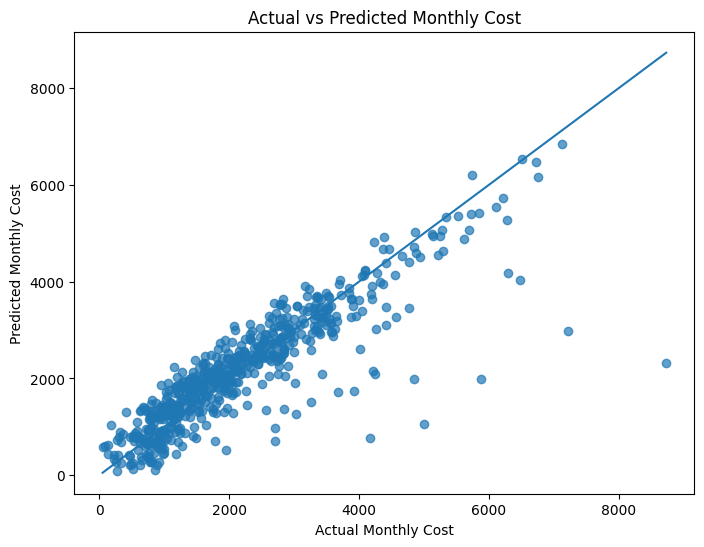

In [10]:
plt.figure(figsize = (8,6))  # Set plot size

plt.scatter(
    results_df["actual"], #x-axis: true monthly cost
    results_df["predicted"], #Y-axis: predicted monthly cost
    alpha = 0.7 # Make points slightly transparent 
)

plt.xlabel("Actual Monthly Cost") # Label x-axis
plt.ylabel("Predicted Monthly Cost") # Label y-axis
plt.title("Actual vs Predicted Monthly Cost") # Add plot title

min_val = min(results_df["actual"].min(), results_df["predicted"].min()) #Get lower bound for diagonal reference line
max_val = max(results_df["actual"].max(), results_df["predicted"].max()) #Get upper bound for diagonal reference line

plt.plot([min_val, max_val], [min_val, max_val])

plt.show() #Display the plot



## 11. Residuals vs predicted values plot 

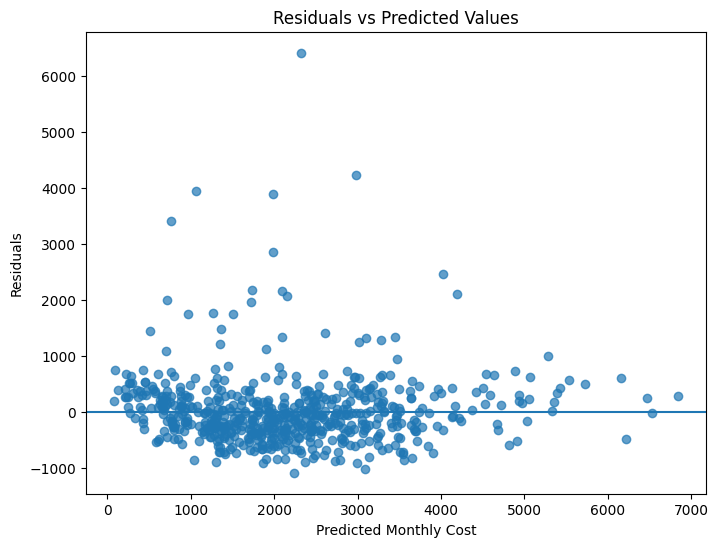

In [11]:
plt.figure(figsize = (8,6)) # Set plot size

plt.scatter(
    results_df["predicted"], # x-axis: predicted monthly cost
    results_df["residual"], # y-axis: residuals
    alpha = 0.7 # Make points slightly transparent
)

plt.axhline(y=0) # Add horizontal reference line at zero residual
plt.xlabel("Predicted Monthly Cost") # label x-axis
plt.ylabel("Residuals") # Label y-axis
plt.title("Residuals vs Predicted Values") # Add plot title

plt.show()



## 12. Residual distribution plot

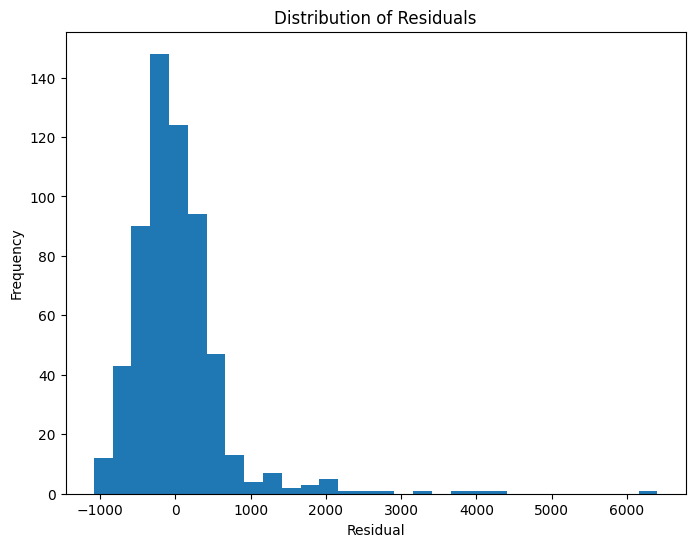

In [12]:
plt.figure(figsize = (8,6)) # Set plot size

plt.hist(
    results_df["residual"], # Plot distribution of residuals
    bins = 30 # Use 30 bars for the histogram
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals") # Add plot title

plt.show() 


## 13. Inspect largest errors

In [13]:
largest_errors = results_df.sort_values(
    "absolute_error", #Sort by error size
    ascending = False # Put biggest errors first
)

largest_errors.head(10)


    

,actual,predicted,residual,absolute_error
1336,8734.22,2325.812693,6408.407307,6408.407307
124,7218.17,2985.310386,4232.859614,4232.859614
408,5004.13,1060.184951,3943.945049,3943.945049
1706,5879.72,1988.866058,3890.853942,3890.853942
457,4163.09,762.892752,3400.197248,3400.197248
685,4841.47,1983.950737,2857.519263,2857.519263
1429,6484.28,4029.539643,2454.740357,2454.740357
0,3920.62,1737.624354,2182.995646,2182.995646
1231,4247.30,2097.684223,2149.615777,2149.615777
1089,6296.58,4188.545271,2108.034729,2108.034729


## Largest Error Interpretation

The largest prediction errors are mostly high-cost members whose actual costs were much higher than predicted.

For example, the largest error has an actual monthly cost above `$8,700`, but the model predicted only about `$2,300`.

This shows that the Ridge model captures average cost patterns reasonably well, but it underpredicts some extreme high-cost cases.

This is expected because the synthetic cost target includes skewed noise and rare acute event costs, which are difficult for a linear model to capture.

## 14. Add error bands

In [14]:
results_df["error_band"] = pd.cut(
    results_df["absolute_error"], # Group members based on absolute error size
    bins = [0, 100, 250, 500, 1000, np.inf], # Define error ranges
    labels = ["0-100", "100-250", "250-500", "500-1000", "1000+"] # Name each error range
)
results_df["error_band"].value_counts().sort_index() # Count how many members fall into each error band

error_band
0-100       107
100-250     142
250-500     201
500-1000    121
1000+        29
Name: count, dtype: int64

## Error Band Interpretation

Most members have prediction errors below `$500`, but a smaller group has errors above `$1,000`.

This confirms that the model performs reasonably for many members but struggles with a smaller number of high-error cases.

In healthcare cost prediction, these high-error cases matter because they often represent the members with the largest financial impact.

## 15. Compare residuals by actual cost group

In [15]:
results_df["actual_cost_group"] = pd.qcut(
    results_df["actual"], # Split members based on actual monthly cost
    q=4, # Create four groups: Lowest to highest cost quartiles
    labels = ["Low", "Medium-Low", "Medium-High", "High"] # Label each quartile
)

results_df.groupby("actual_cost_group")["absolute_error"].mean() # Calculate average error by actual cost group

cost_group_summary = results_df.groupby("actual_cost_group").agg(
    avg_actual_cost = ("actual", "mean"), # Average actual cost within each group
    avg_predicted_cost =  ("predicted", "mean"), # Average predicted cost within each group
    avg_residual = ("residual", "mean"),  # Average underprediction or overprediction
    avg_absolute_error = ("absolute_error", "mean"), # Average error size
    member_count = ("actual", "count") # Number of members in each group
)

cost_group_summary # Display model performance by actual cost group

,avg_actual_cost,avg_predicted_cost,avg_residual,avg_absolute_error,member_count
actual_cost_group,,,,,
Low,780.166200,912.142967,-131.976767,328.881857,150
Medium-Low,1530.986867,1715.795911,-184.809045,346.328143,150
Medium-High,2381.197067,2439.975459,-58.778393,336.265248,150
High,4033.156000,3575.754254,457.401746,605.199982,150


## Residuals by Cost Group Interpretation

The model overpredicts costs for the low and medium-low cost groups, shown by negative average residuals.

The model underpredicts the high-cost group, shown by a positive average residual of about `$457`.

The high-cost group also has the highest average absolute error, about `$605`.

This suggests that the model compresses predictions toward the middle: it predicts low-cost members too high and high-cost members too low.

That is a common limitation of linear regression models when the target variable is right-skewed.

## 16. Findings


The purpose of this notebook was to inspect residual behavior after tuning the Ridge regression model.

The residual was calculated as:

`actual monthly cost - predicted monthly cost`

A positive residual means the model underpredicted cost. A negative residual means the model overpredicted cost.

The tuned Ridge model achieved an MAE of about `$404`, RMSE of about `$654`, and R² of about `0.764`.

The actual-vs-predicted plot showed that the model follows the general cost pattern, but it does not fully capture very high-cost members.

The residuals-vs-predicted plot was used to check whether errors were randomly scattered around zero. Any visible funnel shape, curve, or widening spread would suggest that the linear model is missing nonlinear patterns.

The residual distribution showed that errors are not perfectly normal, which is expected in healthcare cost prediction because monthly cost is right-skewed.

The largest-error table showed that the biggest errors are mostly underpredicted high-cost members.

The cost-group analysis showed that the model tends to overpredict lower-cost members and underpredict higher-cost members.

This suggests that the Ridge model captures average cost patterns reasonably well but struggles with extreme high-cost cases.

A logical next step is to compare this model with approaches that better handle skewed cost outcomes, such as log-transformed target regression, Random Forest regression, or Gradient Boosting regression.